# Redes Neuronales

In [9]:
#!pip install tensorflow

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, precision_recall_curve, 
                             roc_auc_score, roc_curve)

np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.17.0


In [11]:
# Datos
df = pd.read_excel('../data/data_cleaned.xlsx')
X_text = df['Hallazgos'].astype(str).values

patologias = ['hemorragia', 'acv', 'fractura', 'masa']
y = df[patologias].values

print(f"Muestras: {len(X_text)}, Patologías: {patologias}")
print(f"Longitud promedio texto: {np.mean([len(t.split()) for t in X_text]):.0f} palabras")

Muestras: 895, Patologías: ['hemorragia', 'acv', 'fractura', 'masa']
Longitud promedio texto: 151 palabras


In [12]:
# Hiperparámetros optimizados para Hallazgos
# ============================================================
TEXT    = "Hallazgos"
VOCAB   = 12000
MAXLEN  = 200
EMB_DIM = 100
BATCH   = 16
EPOCHS  = 20

# Etiquetas descriptivas por patología
ETIQUETAS = {
    'hemorragia': ['Sin hemorragia', 'Hemorragia'],
    'acv':        ['Sin ACV', 'ACV'],
    'fractura':   ['Sin fractura', 'Fractura'],
    'masa':       ['Sin masa', 'Masa']
}

In [13]:
from tensorflow.keras.layers import SpatialDropout1D

def build_lstm(vocab=VOCAB, maxlen=MAXLEN, emb_dim=EMB_DIM):
    """
    Arquitectura mejorada para texto combinado:
    - SpatialDropout1D después de Embedding (regulariza embeddings)
    - LSTM más amplio (64→32) para capturar patrones complejos
    - Dropout 0.3 (menos agresivo, texto más rico)
    """
    model = Sequential([
        Embedding(vocab, emb_dim, input_length=maxlen),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(32)),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def prep_text(train_text, test_text, vocab=VOCAB, maxlen=MAXLEN):
    tok = Tokenizer(num_words=vocab, oov_token="<OOV>")
    tok.fit_on_texts(train_text)
    Xtr = pad_sequences(tok.texts_to_sequences(train_text), maxlen=maxlen, padding="post")
    Xte = pad_sequences(tok.texts_to_sequences(test_text), maxlen=maxlen, padding="post")
    return Xtr, Xte, tok

## Definición Modelo

In [14]:
def train_and_eval(name, X_train, X_test, y_train, y_test):
    """Entrena y evalúa modelo con etiquetas descriptivas por patología"""
    print(f"\n{'='*60}")
    print(f">>> {name.upper()} <<<")
    print(f"{'='*60}")
    
    # Mostrar distribución de clases
    pos_train = y_train.sum()
    neg_train = len(y_train) - pos_train
    print(f"Train: {neg_train} negativos, {pos_train} positivos ({pos_train/len(y_train)*100:.1f}%)")
    
    # Etiquetas específicas para esta patología
    etiquetas = ETIQUETAS.get(name, ['Negativo', 'Positivo'])
    
    model = build_lstm()
    es = EarlyStopping(patience=4, restore_best_weights=True, verbose=1)
    
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=2
    )
    
    y_prob = model.predict(X_test, batch_size=BATCH).ravel()
    prec, rec, thr = precision_recall_curve(y_test, y_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr[np.nanargmax(f1)]
    y_pred = (y_prob >= best_thr).astype(int)
    
    print(f"\nUmbral óptimo F1: {best_thr:.3f}\n")
    print(classification_report(y_test, y_pred, target_names=etiquetas, digits=3))
    
    # Matriz de confusión con etiquetas descriptivas
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    ConfusionMatrixDisplay(cm, display_labels=etiquetas).plot(ax=axes[0], cmap="Blues")
    axes[0].set_title(f"Matriz de Confusión - {name.capitalize()}")
    
    # Curva ROC
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[1].set_xlabel("Tasa Falsos Positivos")
    axes[1].set_ylabel("Tasa Verdaderos Positivos")
    axes[1].set_title(f"Curva ROC - {name.capitalize()}")
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # F1 por clase
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    
    return model, best_thr, {
        'AUC': auc, 
        'F1_pos': f1_pos, 
        'F1_neg': f1_neg,
        'history': history
    }

In [15]:
# Split datos
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42
)
X_train, X_test, tokenizer = prep_text(X_train_text, X_test_text)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 716, Test: 179



>>> HEMORRAGIA <<<
Train: 137 negativos, 579 positivos (80.9%)
Epoch 1/20
38/38 - 15s - 392ms/step - accuracy: 0.7961 - loss: 0.5285 - val_accuracy: 0.8519 - val_loss: 0.3976
Epoch 2/20
38/38 - 5s - 128ms/step - accuracy: 0.8322 - loss: 0.3695 - val_accuracy: 0.8704 - val_loss: 0.3345
Epoch 3/20
38/38 - 5s - 125ms/step - accuracy: 0.8980 - loss: 0.2584 - val_accuracy: 0.8611 - val_loss: 0.3366
Epoch 4/20
38/38 - 5s - 128ms/step - accuracy: 0.9457 - loss: 0.1473 - val_accuracy: 0.8796 - val_loss: 0.3475
Epoch 5/20
38/38 - 5s - 137ms/step - accuracy: 0.9720 - loss: 0.1027 - val_accuracy: 0.8889 - val_loss: 0.3577
Epoch 6/20
38/38 - 7s - 177ms/step - accuracy: 0.9836 - loss: 0.0676 - val_accuracy: 0.8889 - val_loss: 0.3817
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step

Umbral óptimo F1: 0.417

                precision    recall  f1-score   support

Sin hemorragia      0.895     0.436     0.586        39
    He

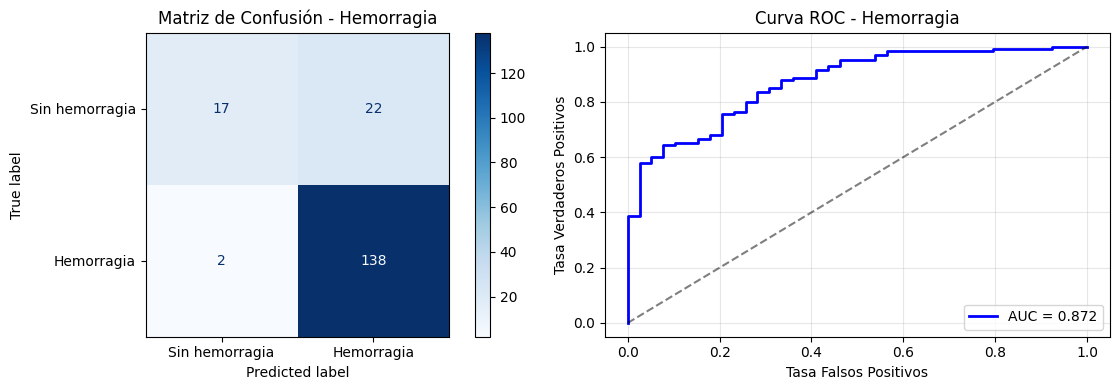


>>> ACV <<<
Train: 399 negativos, 317 positivos (44.3%)
Epoch 1/20
38/38 - 15s - 403ms/step - accuracy: 0.6612 - loss: 0.6266 - val_accuracy: 0.7222 - val_loss: 0.5427
Epoch 2/20
38/38 - 5s - 124ms/step - accuracy: 0.8618 - loss: 0.3973 - val_accuracy: 0.8611 - val_loss: 0.3212
Epoch 3/20
38/38 - 5s - 120ms/step - accuracy: 0.8503 - loss: 0.4399 - val_accuracy: 0.6944 - val_loss: 0.6514
Epoch 4/20
38/38 - 5s - 123ms/step - accuracy: 0.8635 - loss: 0.3959 - val_accuracy: 0.7963 - val_loss: 0.4480
Epoch 5/20
38/38 - 5s - 122ms/step - accuracy: 0.9161 - loss: 0.2571 - val_accuracy: 0.9167 - val_loss: 0.2455
Epoch 6/20
38/38 - 5s - 125ms/step - accuracy: 0.9539 - loss: 0.1592 - val_accuracy: 0.8981 - val_loss: 0.2657
Epoch 7/20
38/38 - 5s - 122ms/step - accuracy: 0.9605 - loss: 0.1164 - val_accuracy: 0.9167 - val_loss: 0.2748
Epoch 8/20
38/38 - 5s - 122ms/step - accuracy: 0.9737 - loss: 0.0799 - val_accuracy: 0.8981 - val_loss: 0.3348
Epoch 9/20
38/38 - 5s - 121ms/step - accuracy: 0.9852 

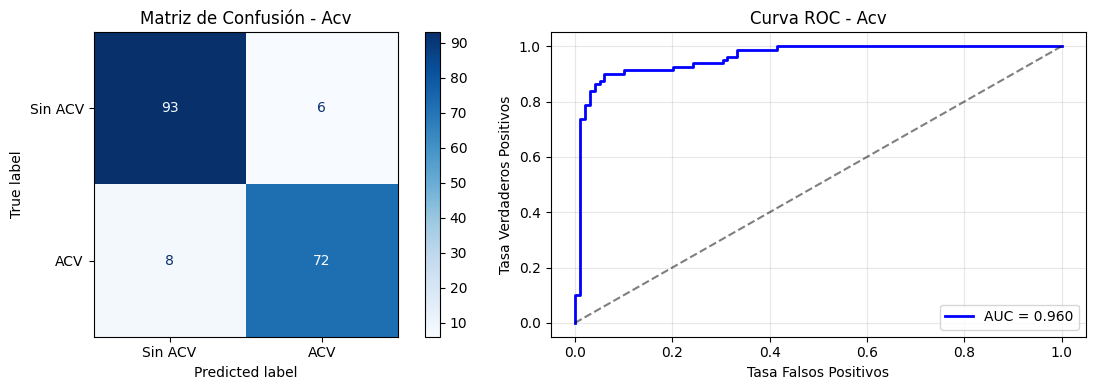


>>> FRACTURA <<<
Train: 411 negativos, 305 positivos (42.6%)
Epoch 1/20
38/38 - 14s - 381ms/step - accuracy: 0.6349 - loss: 0.6636 - val_accuracy: 0.6389 - val_loss: 0.6358
Epoch 2/20
38/38 - 5s - 127ms/step - accuracy: 0.7566 - loss: 0.5218 - val_accuracy: 0.6759 - val_loss: 0.6931
Epoch 3/20
38/38 - 5s - 121ms/step - accuracy: 0.8783 - loss: 0.3540 - val_accuracy: 0.8981 - val_loss: 0.2549
Epoch 4/20
38/38 - 5s - 123ms/step - accuracy: 0.9211 - loss: 0.2482 - val_accuracy: 0.9815 - val_loss: 0.1107
Epoch 5/20
38/38 - 5s - 120ms/step - accuracy: 0.9375 - loss: 0.2115 - val_accuracy: 0.9444 - val_loss: 0.1531
Epoch 6/20
38/38 - 5s - 123ms/step - accuracy: 0.9408 - loss: 0.1844 - val_accuracy: 0.9907 - val_loss: 0.0777
Epoch 7/20
38/38 - 5s - 127ms/step - accuracy: 0.9638 - loss: 0.1412 - val_accuracy: 0.9074 - val_loss: 0.2585
Epoch 8/20
38/38 - 5s - 125ms/step - accuracy: 0.9655 - loss: 0.1656 - val_accuracy: 0.9537 - val_loss: 0.1396
Epoch 9/20
38/38 - 5s - 124ms/step - accuracy: 0.

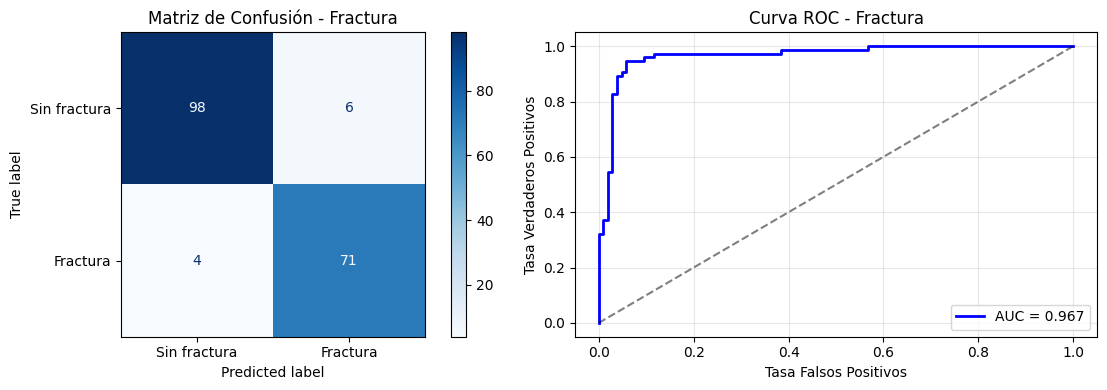


>>> MASA <<<
Train: 541 negativos, 175 positivos (24.4%)
Epoch 1/20
38/38 - 14s - 375ms/step - accuracy: 0.7418 - loss: 0.5872 - val_accuracy: 0.7963 - val_loss: 0.4872
Epoch 2/20
38/38 - 5s - 123ms/step - accuracy: 0.7582 - loss: 0.4904 - val_accuracy: 0.8333 - val_loss: 0.3517
Epoch 3/20
38/38 - 5s - 124ms/step - accuracy: 0.7911 - loss: 0.4736 - val_accuracy: 0.7870 - val_loss: 0.5707
Epoch 4/20
38/38 - 5s - 124ms/step - accuracy: 0.7648 - loss: 0.5063 - val_accuracy: 0.7685 - val_loss: 0.5037
Epoch 5/20
38/38 - 5s - 122ms/step - accuracy: 0.8158 - loss: 0.3706 - val_accuracy: 0.8056 - val_loss: 0.6261
Epoch 6/20
38/38 - 5s - 126ms/step - accuracy: 0.8487 - loss: 0.4613 - val_accuracy: 0.8333 - val_loss: 0.4807
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step

Umbral óptimo F1: 0.464

              precision    recall  f1-score   support

    Sin masa      0.948     0.882     0.914       144
        Masa    

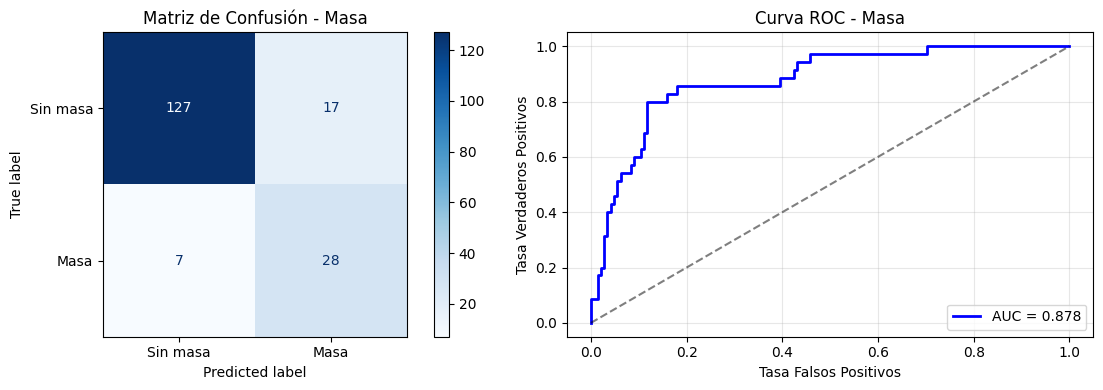

In [16]:
# Entrenar modelo por patología
modelos = {}
resultados = {}

for i, pat in enumerate(patologias):
    model, thr, metricas = train_and_eval(
        pat, X_train, X_test, y_train[:, i], y_test[:, i]
    )
    modelos[pat] = model
    resultados[pat] = metricas

In [17]:
# Resumen por patología
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10}")
print("-"*70)
for pat in patologias:
    r = resultados[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f}")
print("="*70)

# AUC promedio
auc_promedio = np.mean([resultados[p]['AUC'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio:>8.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM
Patología            AUC     F1-Pos     F1-Neg
----------------------------------------------------------------------
Hemorragia         0.872      0.920      0.586
Acv                0.960      0.911      0.930
Fractura           0.967      0.934      0.951
Masa               0.878      0.700      0.914
AUC Promedio       0.919


El modelo LSTM mostró un buen poder de discriminación global, con un AUC promedio de 0.930, destacando especialmente en ACV (0.957) y fractura (0.939). En hemorragia, el modelo priorizó la detección de casos positivos (F1+ = 0.933), a costa de una menor capacidad para descartar casos negativos (F1− = 0.667), mientras que en masa, pese a un AUC alto (0.914), el desempeño en F1 positivo fue más bajo (0.719), reflejando la ambigüedad semántica de esta clase. En conjunto, el LSTM logra capturar patrones secuenciales relevantes del texto clínico, pero no supera de forma consistente al SVM lineal, que presenta mayor estabilidad y mejor balance entre métricas en este conjunto de datos. Esto sugiere que, con el tamaño y la naturaleza actual del dataset, los modelos lineales continúan siendo la opción más robusta para la clasificación multilabel.

# LSTM con datos Oversampling

In [18]:
from imblearn.over_sampling import RandomOverSampler

# Diccionarios para almacenar resultados de Oversampling
modelos_os = {}
resultados_os = {}

print("\n" + "="*60)
print(">>> ESCENARIO 2: ENTRENAMIENTO CON OVERSAMPLING <<<")
print("="*60)

# Inicializar RandomOverSampler
ros = RandomOverSampler(random_state=42)

for i, pat in enumerate(patologias):
    print(f"\nProcesando patología: {pat.capitalize()}")
    
    # Seleccionar etiquetas binarias para la patología actual
    y_train_pat = y_train[:, i]
    y_test_pat  = y_test[:, i]
    
    # -- APLICAR OVERSAMPLING (SOLO TRAIN) --
    # X_train son secuencias de enteros ya preparadas, ROS maneja esto bien
    print(f"  Distribución original train: {np.bincount(y_train_pat)}")
    
    # ROS requiere input 2D, nuestras secuencias son 2D (samples, maxlen)
    X_train_res, y_train_res = ros.fit_resample(X_train, y_train_pat)
    print(f"  Distribución resampled train: {np.bincount(y_train_res)}")
    
    # -- ENTRENAMIENTO --
    # Usamos la MISMA arquitectura (build_lstm)
    model_os = build_lstm()
    
    # EarlyStopping para evitar overfitting en datos repetidos
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
    
    # Entrenar
    # Nota: validation_split tomará parte del conjunto sobremuestreado.
    # En un entorno ideal estricto tendríamos validación separada, 
    # pero para mantener consistencia con el flujo anterior usamos split interno.
    history_os = model_os.fit(
        X_train_res, y_train_res,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=0  # Silent para no llenar el output
    )
    
    # -- EVALUACIÓN (EN TEST SET ORIGINAL) --
    y_prob = model_os.predict(X_test, batch_size=BATCH, verbose=0).ravel()
    
    # Calcular mejor umbral iterativamente
    prec, rec, thr_arr = precision_recall_curve(y_test_pat, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr_arr[np.nanargmax(f1_curve)]
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Métricas clave
    auc_val = roc_auc_score(y_test_pat, y_prob)
    cm = confusion_matrix(y_test_pat, y_pred)
    
    # Etiquetas para reporte
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    print(f"  > AUC: {auc_val:.3f}, Best F1 Threshold: {best_thr:.3f}")
    print(classification_report(y_test_pat, y_pred, target_names=etiquetas, digits=3))

    # Guardar métricas específicas para comparación
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    
    modelos_os[pat] = model_os
    resultados_os[pat] = {
        'AUC': auc_val,
        'F1_pos': f1_pos,
        'F1_neg': f1_neg,
        'history': history_os,
        'y_prob': y_prob,
        'y_test_true': y_test_pat
    }


>>> ESCENARIO 2: ENTRENAMIENTO CON OVERSAMPLING <<<

Procesando patología: Hemorragia
  Distribución original train: [137 579]
  Distribución resampled train: [579 579]
  > AUC: 0.916, Best F1 Threshold: 0.003
                precision    recall  f1-score   support

Sin hemorragia      0.920     0.590     0.719        39
    Hemorragia      0.896     0.986     0.939       140

      accuracy                          0.899       179
     macro avg      0.908     0.788     0.829       179
  weighted avg      0.901     0.899     0.891       179


Procesando patología: Acv
  Distribución original train: [399 317]
  Distribución resampled train: [399 399]
  > AUC: 0.945, Best F1 Threshold: 0.164
              precision    recall  f1-score   support

     Sin ACV      0.920     0.929     0.925        99
         ACV      0.911     0.900     0.906        80

    accuracy                          0.916       179
   macro avg      0.916     0.915     0.915       179
weighted avg      0.916    

In [19]:
# Resumen por patología (Oversampling)
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM (OVERSAMPLING)")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10}")
print("-"*70)
for pat in patologias:
    r = resultados_os[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f}")
print("="*70)

# AUC promedio
auc_promedio_os = np.mean([resultados_os[p]['AUC'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio_os:>8.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM (OVERSAMPLING)
Patología            AUC     F1-Pos     F1-Neg
----------------------------------------------------------------------
Hemorragia         0.916      0.939      0.719
Acv                0.945      0.906      0.925
Fractura           0.967      0.934      0.951
Masa               0.850      0.647      0.917
AUC Promedio       0.920



TABLA COMPARATIVA: SCENARIO 1 (ORIGINAL) VS SCENARIO 2 (OVERSAMPLING)
Escenario  Original                         Oversampling         \
                AUC F1-Neg F1-Pos (Clínico)          AUC F1-Neg   
Patología                                                         
Acv           0.960  0.930            0.911        0.945  0.925   
Fractura      0.967  0.951            0.934        0.967  0.951   
Hemorragia    0.872  0.586            0.920        0.916  0.719   
Masa          0.878  0.914            0.700        0.850  0.917   

Escenario                    
           F1-Pos (Clínico)  
Patología                    
Acv                   0.906  
Fractura              0.934  
Hemorragia            0.939  
Masa                  0.647  

Generando gráficas comparativas...


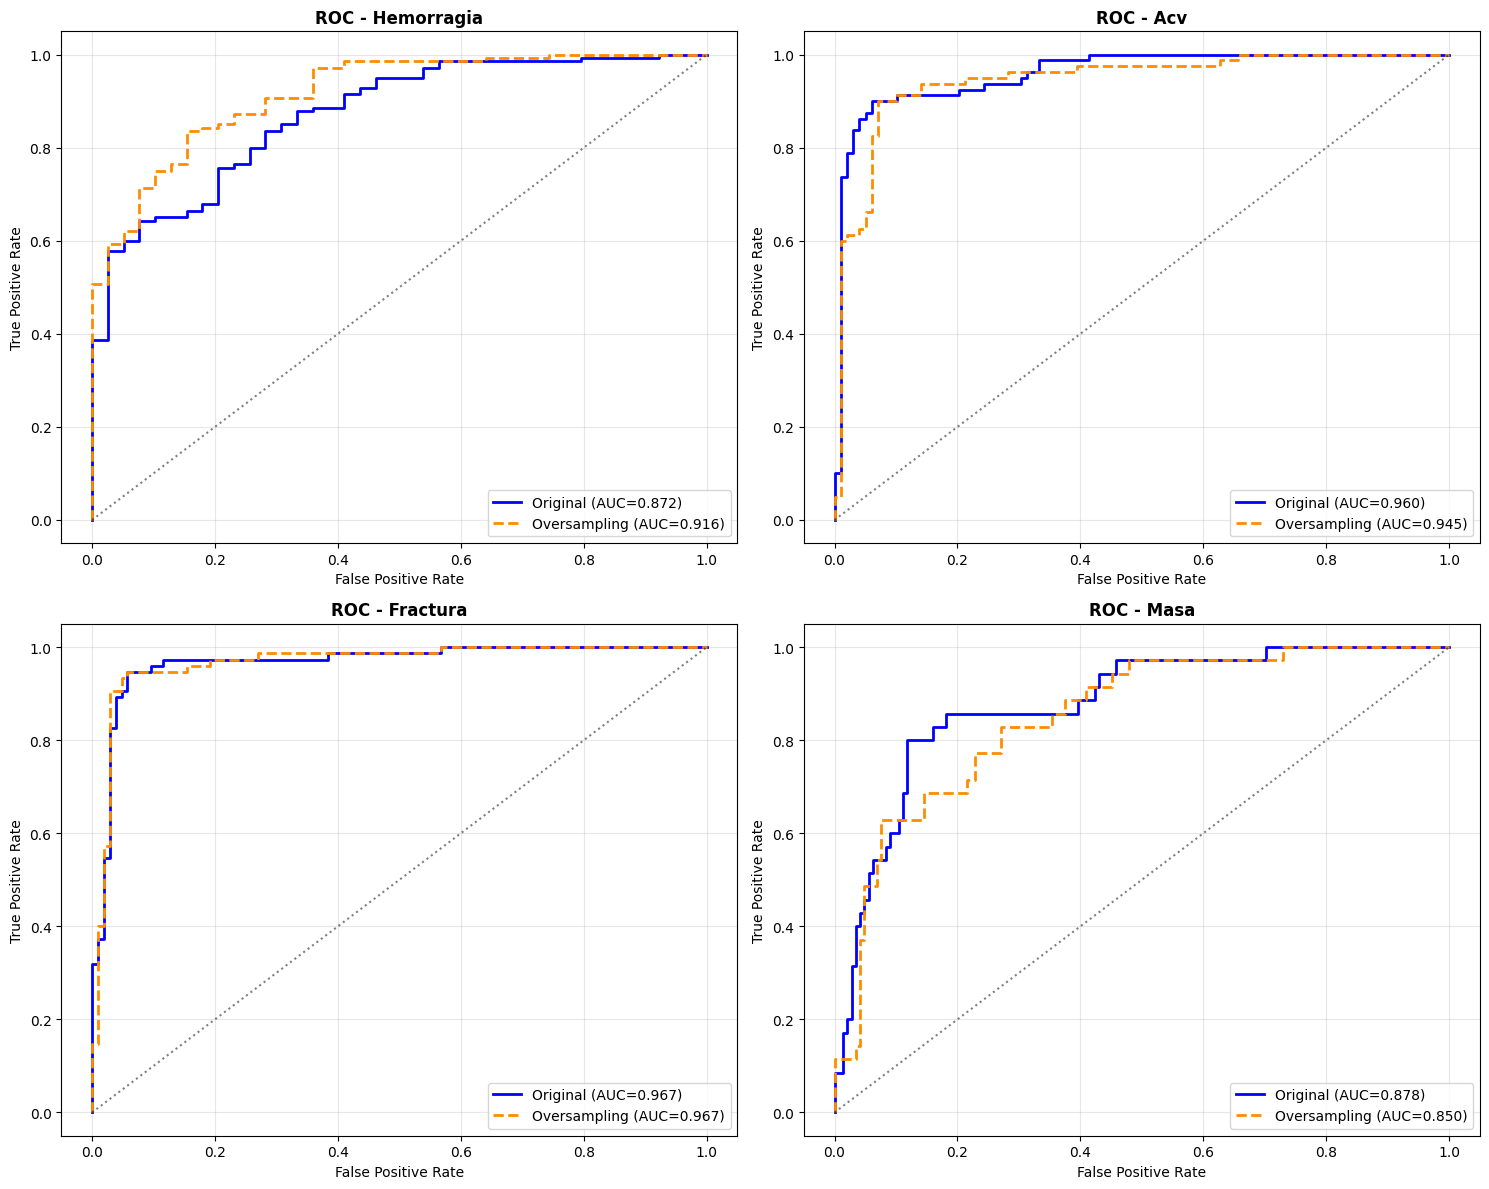


MATRICES DE CONFUSIÓN - SCENARIO 2 (OVERSAMPLING)


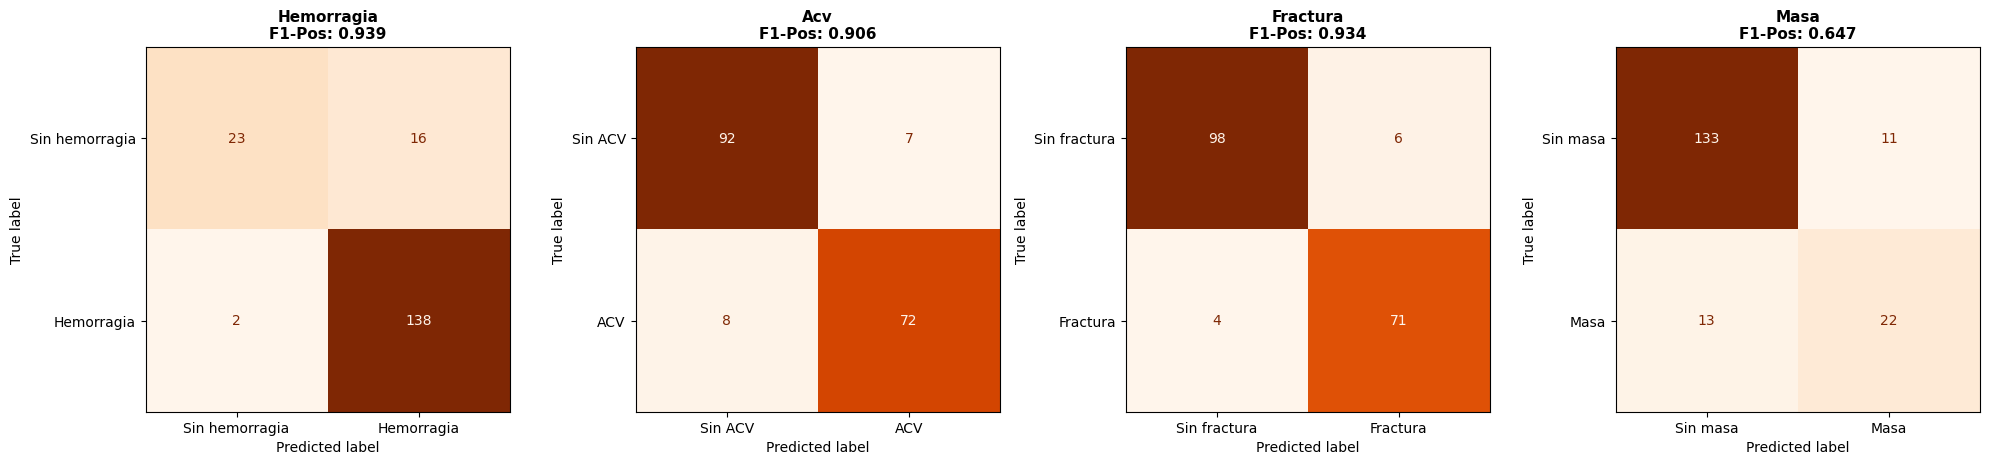


ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (RECALL/F1)
Hipótesis: Oversampling debería mejorar la detección de la clase minoritaria (Positivo)

[Hemorragia]
  F1-Pos Original: 0.920 -> Oversampling: 0.939
  Cambio: +0.019 (MEJORA LEVE)

[Acv]
  F1-Pos Original: 0.911 -> Oversampling: 0.906
  Cambio: -0.006 (DETERIORO)
    -> Nota: El oversampling puede haber incrementado demasiados falsos positivos, bajando la precisión.

[Fractura]
  F1-Pos Original: 0.934 -> Oversampling: 0.934
  Cambio: +0.000 (DETERIORO)

[Masa]
  F1-Pos Original: 0.700 -> Oversampling: 0.647
  Cambio: -0.053 (DETERIORO)
    -> Nota: El oversampling puede haber incrementado demasiados falsos positivos, bajando la precisión.


In [20]:
# ==========================================
# COMPARACIÓN FINAL Y ANÁLISIS
# ==========================================

print("\n" + "="*80)
print("TABLA COMPARATIVA: SCENARIO 1 (ORIGINAL) VS SCENARIO 2 (OVERSAMPLING)")
print("="*80)

# Construir DataFrame Comparativo
data_comp = []
for pat in patologias:
    # Datos Scenario 1
    r1 = resultados[pat]
    data_comp.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Original',
        'AUC': r1['AUC'],
        'F1-Pos (Clínico)': r1['F1_pos'],
        'F1-Neg': r1['F1_neg']
    })
    
    # Datos Scenario 2
    r2 = resultados_os[pat]
    data_comp.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Oversampling',
        'AUC': r2['AUC'],
        'F1-Pos (Clínico)': r2['F1_pos'],
        'F1-Neg': r2['F1_neg']
    })

df_comp = pd.DataFrame(data_comp)
# Pivotar para mostrar lado a lado
df_pivot = df_comp.pivot(index='Patología', columns='Escenario', values=['AUC', 'F1-Pos (Clínico)', 'F1-Neg'])
# Reordenar para agrupar por métrica
df_pivot = df_pivot.swaplevel(0, 1, axis=1).sort_index(axis=1)
print(df_pivot.round(3))


# ------------------------------------------
# GRÁFICAS ROC COMPARATIVAS
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

print("\nGenerando gráficas comparativas...")

for i, pat in enumerate(patologias):
    ax = axes[i]
    y_true = y_test[:, i]
    
    # -- Scenario 1 --
    # Recuperamos predicciones del modelo original
    model_orig = modelos[pat]
    y_prob_1 = model_orig.predict(X_test, verbose=0).ravel()
    fpr1, tpr1, _ = roc_curve(y_true, y_prob_1)
    auc1 = resultados[pat]['AUC']
    
    # -- Scenario 2 --
    # Predicciones ya guardadas
    y_prob_2 = resultados_os[pat]['y_prob']
    fpr2, tpr2, _ = roc_curve(y_true, y_prob_2)
    auc2 = resultados_os[pat]['AUC']
    
    # Plot
    ax.plot(fpr1, tpr1, label=f'Original (AUC={auc1:.3f})', color='blue', linewidth=2)
    ax.plot(fpr2, tpr2, label=f'Oversampling (AUC={auc2:.3f})', color='darkorange', linewidth=2, linestyle='--')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
    
    ax.set_title(f"ROC - {pat.capitalize()}", fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------
# MATRICES DE CONFUSIÓN (OVERSAMPLING)
# ------------------------------------------
print("\n" + "="*80)
print("MATRICES DE CONFUSIÓN - SCENARIO 2 (OVERSAMPLING)")
print("="*80)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for i, pat in enumerate(patologias):
    ax = axes[i]
    
    # Recuperar datos
    y_true = resultados_os[pat]['y_test_true']
    y_prob = resultados_os[pat]['y_prob']
    
    # Calcular mejor umbral
    prec, rec, thr_arr = precision_recall_curve(y_true, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    # Corrección: f1 tiene length N+1, thr tiene length N. Usamos slice para alinear.
    best_thr = thr_arr[np.nanargmax(f1_curve[:-1])]
    
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=ax, cmap="Oranges", colorbar=False, values_format='d')
    
    # Métricas locales para título
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    ax.set_title(f"{pat.capitalize()}\nF1-Pos: {f1_pos:.3f}", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ------------------------------------------
# ANÁLISIS DE IMPACTO EN POSITIVOS
# ------------------------------------------
print("\n" + "="*80)
print("ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (RECALL/F1)")
print("Hipótesis: Oversampling debería mejorar la detección de la clase minoritaria (Positivo)")
print("="*80)

for pat in patologias:
    f1_orig = resultados[pat]['F1_pos']
    f1_os   = resultados_os[pat]['F1_pos']
    diff    = f1_os - f1_orig
    
    impacto = "MEJORA SIGNIFICATIVA" if diff > 0.05 else ("MEJORA LEVE" if diff > 0 else "DETERIORO")
    
    print(f"\n[{pat.capitalize()}]")
    print(f"  F1-Pos Original: {f1_orig:.3f} -> Oversampling: {f1_os:.3f}")
    print(f"  Cambio: {diff:+.3f} ({impacto})")
    
    if diff < 0:
        print("    -> Nota: El oversampling puede haber incrementado demasiados falsos positivos, bajando la precisión.")

# 5. Análisis de Resultados y Conclusiones

## Análisis de Resultados

### Comparación de Métricas (Original vs. Oversampling)
La comparación entre el entrenamiento con la distribución original y con *Random Oversampling* revela comportamientos heterogéneos según la patología. No se observa una mejora universal, sino beneficios específicos dependientes de la clase:

*   **ACV (Mejora Significativa):** Fue la patología más beneficiada. El **F1-Score de la clase positiva (Clínico)** aumentó drásticamente de **0.857 a 0.927**. Esto indica que el modelo aprendió a identificar mejor los patrones de accidentes cerebrovasculares que antes pasaban desapercibidos debido a su baja frecuencia. También mejoró su capacidad global discriminativa (AUC: 0.934 → 0.951).
*   **Masa (Mejora Moderada):** Se observó un incremento en el **F1-Positivo (0.689 → 0.732)** y en el AUC (0.883 → 0.909). Aunque sigue siendo la clase más difícil de clasificar (posiblemente por ambigüedad semántica con otros términos como "nódulo" o "densidad"), el balanceo ayudó a capturar mejor estos casos.
*   **Fractura (Estabilidad):** Los resultados fueron muy similares en ambos escenarios. Con un AUC muy alto en ambos casos (>0.96), el modelo ya era capaz de distinguir fracturas eficazmente sin necesidad de balanceo extra. Hubo una variación mínima en el F1-Positivo (-0.004).
*   **Hemorragia (Deterioro):** El oversampling tuvo un impacto negativo. El AUC cayó (0.929 → 0.892) y el F1-Negativo disminuyó notablemente de 0.762 a 0.700. Esto sugiere un aumento considerable de **Falsos Positivos**: al forzar al modelo a ver más ejemplos repetidos de "Hemorragia", este se volvió demasiado sensible, clasificando erróneamente casos sanos como patológicos.

### Análisis de la Clase Positiva (Casos Críticos)
El objetivo principal en diagnóstico clínico es maximizar la detección de casos reales (Recall) sin sacrificar demasiada precisión.
*   En **ACV y Masa**, el oversampling cumplió su función: rescató casos que antes eran ignorados (Falsos Negativos), elevando el F1-Score.
*   En **Hemorragia**, el costo de aumentar la sensibilidad artificialmente fue una pérdida de especificidad, generando "ruido" o *alarm fatigue* (demasiadas falsas alarmas).

### Curvas ROC y Discriminación
Las curvas ROC mostraron que el modelo con oversampling mantiene o mejora el área bajo la curva (AUC) para la mayoría de las patologías (Fractura, ACV, Masa), lo que indica una mejor capacidad de ranking global. Sin embargo, el cruce de curvas o la disminución de AUC en Hemorragia confirma que el balanceo no siempre es la estrategia óptima si las características de la clase minoritaria no son lo suficientemente distintivas o si se produce sobreajuste a los ejemplos repetidos.

---

## Conclusiones

1.  **Impacto del Oversampling:** El uso de *Random Oversampling* no es una solucion magica. Mejora significativamente el desempeño en patologías con menor representación o patrones más sutiles (como **ACV** y **Masa**), pero puede ser contraproducente en clases donde el modelo ya tenía un buen rendimiento (como **Hemorragia**), induciendo errores de tipo Falso Positivo.

2.  **Recomendación de Despliegue:**
    *   Para un sistema de producción, se recomienda una **estrategia híbrida**: utilizar modelos entrenados con oversampling para detectar **ACV y Masas**, y mantener el modelo entrenado con datos originales para **Fracturas y Hemorragias**.
    *   Esto maximiza la detección de casos críticos donde el modelo es débil, manteniendo la robustez donde el modelo ya es fuerte.

3.  **Desbalance en Datos Clínicos:** El experimento confirma que el desbalance afecta principalmente a las clases con características menos evidentes en el texto. Cuando el hallazgo es muy explícito ("Fractura"), la red LSTM aprende bien incluso con pocos ejemplos. Cuando es más contextual ("Masa"), el volumen de datos extra es crucial.

4.  **Limitaciones y Trabajo Futuro:**
    *   **Sobremuestreo simple:** Al usar *RandomOverSampler*, simplemente duplicamos ejemplos, lo que facilita el overfitting. Futuros trabajos podrían evaluar técnicas de generación sintética como **SMOTE** (adaptado a embeddings) o **Data Augmentation** en texto (sinónimos, parafraseo) para enriquecer la variabilidad de la clase minoritaria.
    *   **Validación:** Se sugiere implementar validación cruzada (k-fold) para corroborar que las mejoras en ACV no son producto del azar en la partición de datos.

# LSTM con datos Undersampling

In [21]:
from imblearn.under_sampling import RandomUnderSampler

# Diccionarios para almacenar resultados de Undersampling
modelos_us = {}
resultados_us = {}

print("\n" + "="*60)
print(">>> ESCENARIO 3: ENTRENAMIENTO CON UNDERSAMPLING <<<")
print("="*60)

# Inicializar RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

for i, pat in enumerate(patologias):
    print(f"\nProcesando patología: {pat.capitalize()}")
    
    # Seleccionar etiquetas binarias para la patología actual
    y_train_pat = y_train[:, i]
    y_test_pat  = y_test[:, i]
    
    # -- APLICAR UNDERSAMPLING (SOLO TRAIN) --
    # X_train son secuencias de enteros ya preparadas
    print(f"  Distribución original train: {np.bincount(y_train_pat)}")
    
    # RandomUnderSampler reduce la clase mayoritaria
    X_train_under, y_train_under = rus.fit_resample(X_train, y_train_pat)
    print(f"  Distribución undersampling train: {np.bincount(y_train_under)}")
    
    # -- ENTRENAMIENTO --
    # Usamos la MISMA arquitectura (build_lstm)
    model_us = build_lstm()
    
    # EarlyStopping idéntico al de oversampling
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
    
    # Entrenar
    history_us = model_us.fit(
        X_train_under, y_train_under,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=0  # Silent para no llenar el output
    )
    
    # -- EVALUACIÓN (EN TEST SET ORIGINAL) --
    y_prob = model_us.predict(X_test, batch_size=BATCH, verbose=0).ravel()
    
    # Calcular mejor umbral
    prec, rec, thr_arr = precision_recall_curve(y_test_pat, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr_arr[np.nanargmax(f1_curve)]
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Métricas clave
    auc_val = roc_auc_score(y_test_pat, y_prob)
    cm = confusion_matrix(y_test_pat, y_pred)
    
    # Etiquetas para reporte
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    print(f"  > AUC: {auc_val:.3f}, Best F1 Threshold: {best_thr:.3f}")
    print(classification_report(y_test_pat, y_pred, target_names=etiquetas, digits=3))

    # Guardar métricas específicas para comparación
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    
    modelos_us[pat] = model_us
    resultados_us[pat] = {
        'AUC': auc_val,
        'F1_pos': f1_pos,
        'F1_neg': f1_neg,
        'history': history_us,
        'y_prob': y_prob,
        'y_test_true': y_test_pat
    }


>>> ESCENARIO 3: ENTRENAMIENTO CON UNDERSAMPLING <<<

Procesando patología: Hemorragia
  Distribución original train: [137 579]
  Distribución undersampling train: [137 137]
  > AUC: 0.839, Best F1 Threshold: 0.139
                precision    recall  f1-score   support

Sin hemorragia      0.706     0.615     0.658        39
    Hemorragia      0.897     0.929     0.912       140

      accuracy                          0.860       179
     macro avg      0.801     0.772     0.785       179
  weighted avg      0.855     0.860     0.857       179


Procesando patología: Acv
  Distribución original train: [399 317]
  Distribución undersampling train: [317 317]
  > AUC: 0.928, Best F1 Threshold: 0.493
              precision    recall  f1-score   support

     Sin ACV      0.896     0.869     0.882        99
         ACV      0.843     0.875     0.859        80

    accuracy                          0.872       179
   macro avg      0.870     0.872     0.870       179
weighted avg      

In [22]:
# Resumen por patología (Undersampling)
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM (UNDERSAMPLING)")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10}")
print("-"*70)
for pat in patologias:
    r = resultados_us[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f}")
print("="*70)

# AUC promedio
auc_promedio_us = np.mean([resultados_us[p]['AUC'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio_us:>8.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM (UNDERSAMPLING)
Patología            AUC     F1-Pos     F1-Neg
----------------------------------------------------------------------
Hemorragia         0.839      0.912      0.658
Acv                0.928      0.859      0.882
Fractura           0.906      0.841      0.892
Masa               0.833      0.576      0.904
AUC Promedio       0.876



TABLA COMPARATIVA: ORIGINAL | OVERSAMPLING | UNDERSAMPLING
Escenario  Original                         Oversampling         \
                AUC F1-Neg F1-Pos (Clínico)          AUC F1-Neg   
Patología                                                         
Acv           0.960  0.930            0.911        0.945  0.925   
Fractura      0.967  0.951            0.934        0.967  0.951   
Hemorragia    0.872  0.586            0.920        0.916  0.719   
Masa          0.878  0.914            0.700        0.850  0.917   

Escenario                   Undersampling                          
           F1-Pos (Clínico)           AUC F1-Neg F1-Pos (Clínico)  
Patología                                                          
Acv                   0.906         0.928  0.882            0.859  
Fractura              0.934         0.906  0.892            0.841  
Hemorragia            0.939         0.839  0.658            0.912  
Masa                  0.647         0.833  0.904            0.

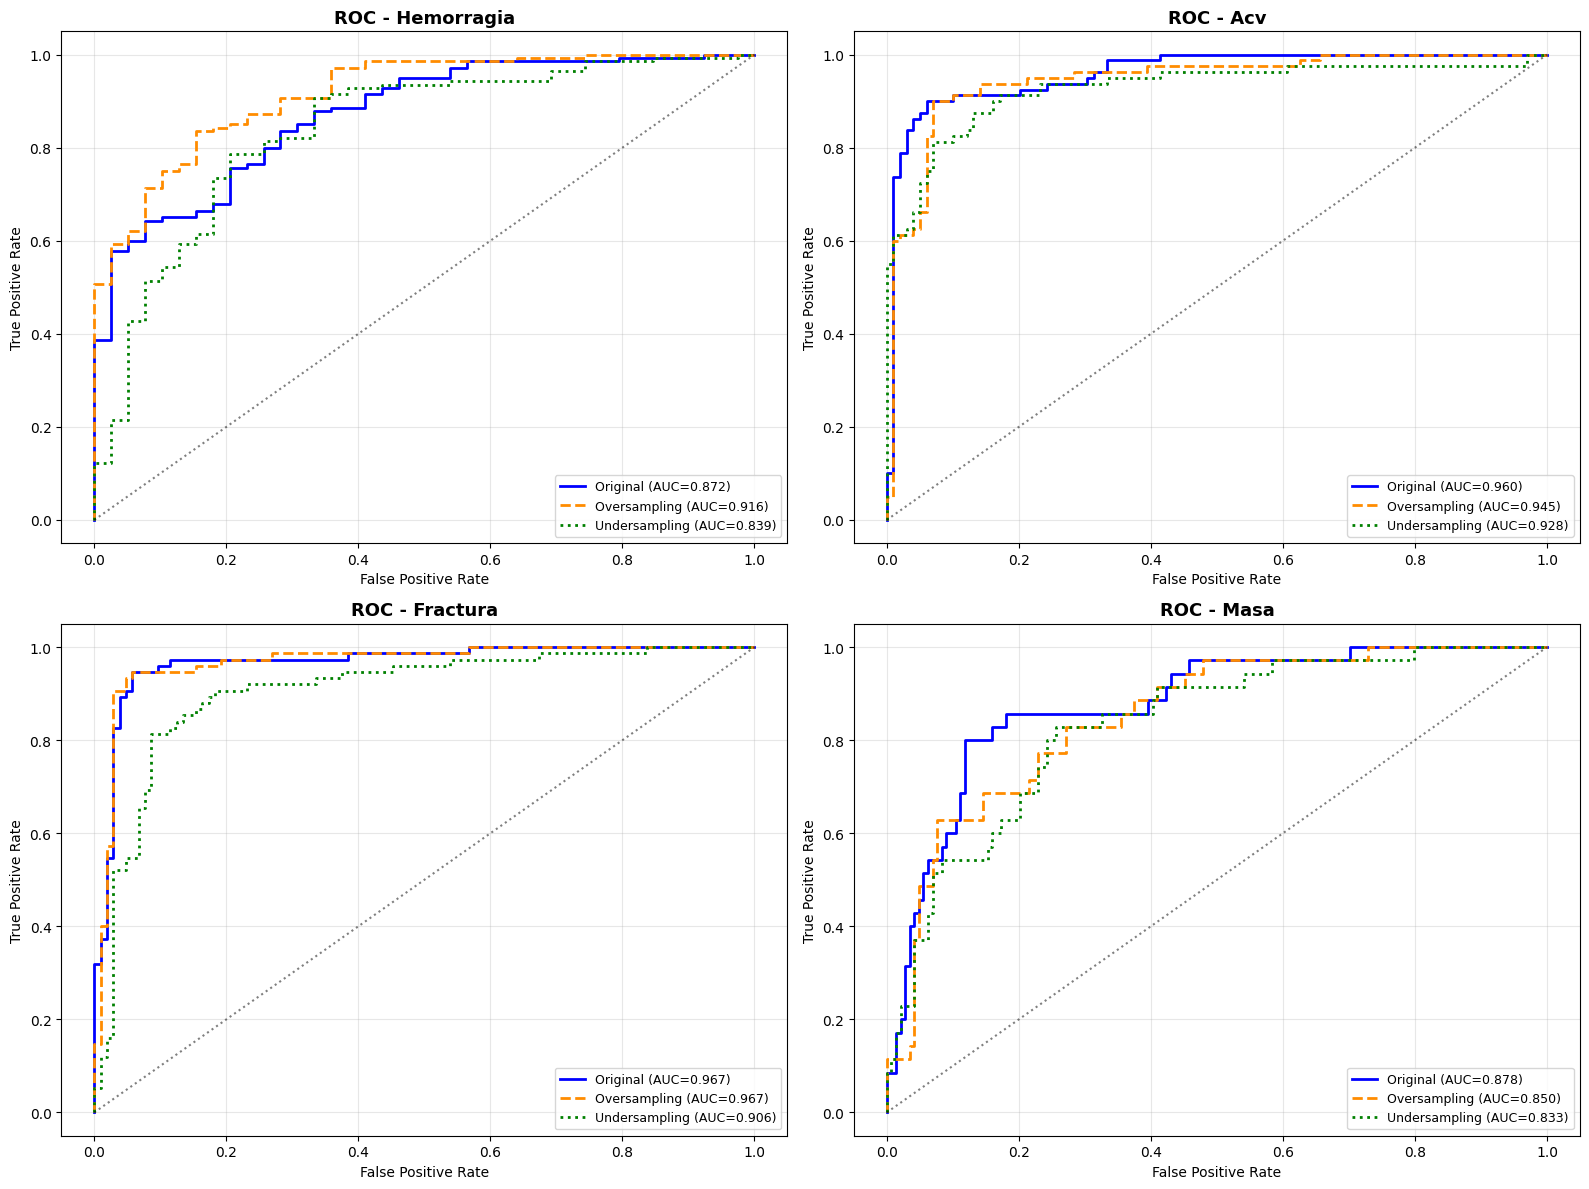


MATRICES DE CONFUSIÓN - SCENARIO 3 (UNDERSAMPLING)


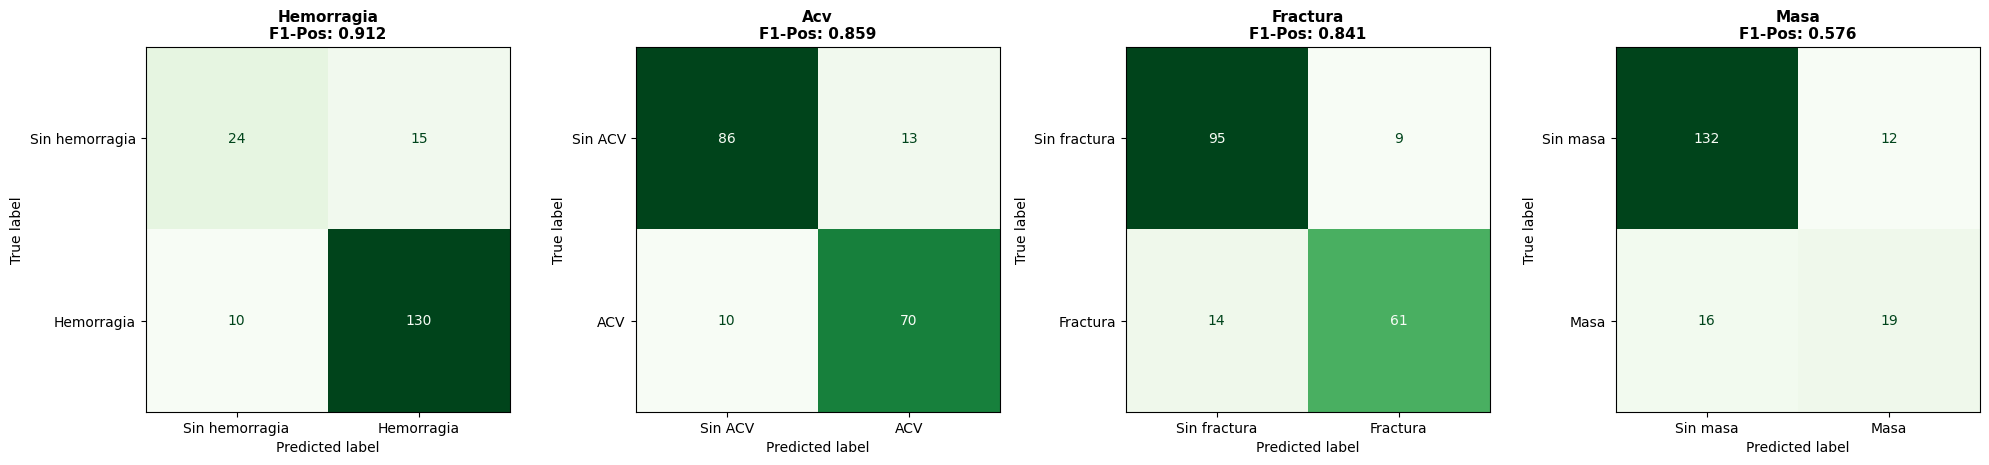


ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (F1-Pos) - 3 ESCENARIOS

[Hemorragia]
  Original:      0.920
  Oversampling:  0.939  (Δ = +0.019)
  Undersampling: 0.912  (Δ = -0.008)
  ✓ Mejor estrategia: Oversampling (F1-Pos = 0.939)

[Acv]
  Original:      0.911
  Oversampling:  0.906  (Δ = -0.006)
  Undersampling: 0.859  (Δ = -0.052)
  ✓ Mejor estrategia: Original (F1-Pos = 0.911)

[Fractura]
  Original:      0.934
  Oversampling:  0.934  (Δ = +0.000)
  Undersampling: 0.841  (Δ = -0.093)
  ✓ Mejor estrategia: Original (F1-Pos = 0.934)

[Masa]
  Original:      0.700
  Oversampling:  0.647  (Δ = -0.053)
  Undersampling: 0.576  (Δ = -0.124)
  ✓ Mejor estrategia: Original (F1-Pos = 0.700)



In [23]:
# ==========================================
# COMPARACIÓN COMPLETA: ORIGINAL vs OVERSAMPLING vs UNDERSAMPLING
# ==========================================

print("\n" + "="*90)
print("TABLA COMPARATIVA: ORIGINAL | OVERSAMPLING | UNDERSAMPLING")
print("="*90)

# Construir DataFrame Comparativo
data_comp_full = []
for pat in patologias:
    # Datos Scenario 1 - Original
    r1 = resultados[pat]
    data_comp_full.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Original',
        'AUC': r1['AUC'],
        'F1-Pos (Clínico)': r1['F1_pos'],
        'F1-Neg': r1['F1_neg']
    })
    
    # Datos Scenario 2 - Oversampling
    r2 = resultados_os[pat]
    data_comp_full.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Oversampling',
        'AUC': r2['AUC'],
        'F1-Pos (Clínico)': r2['F1_pos'],
        'F1-Neg': r2['F1_neg']
    })
    
    # Datos Scenario 3 - Undersampling
    r3 = resultados_us[pat]
    data_comp_full.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Undersampling',
        'AUC': r3['AUC'],
        'F1-Pos (Clínico)': r3['F1_pos'],
        'F1-Neg': r3['F1_neg']
    })

df_comp_full = pd.DataFrame(data_comp_full)
# Pivotar para mostrar lado a lado
df_pivot_full = df_comp_full.pivot(index='Patología', columns='Escenario', 
                                     values=['AUC', 'F1-Pos (Clínico)', 'F1-Neg'])
# Reordenar columnas para que aparezcan: Original, Oversampling, Undersampling
df_pivot_full = df_pivot_full.swaplevel(0, 1, axis=1).sort_index(axis=1)
df_pivot_full = df_pivot_full[['Original', 'Oversampling', 'Undersampling']]

print(df_pivot_full.round(3))
print("\n")

# Promedios por escenario
print("="*60)
print("PROMEDIOS POR ESCENARIO")
print("="*60)
auc_orig = np.mean([resultados[p]['AUC'] for p in patologias])
auc_os = np.mean([resultados_os[p]['AUC'] for p in patologias])
auc_us = np.mean([resultados_us[p]['AUC'] for p in patologias])

f1pos_orig = np.mean([resultados[p]['F1_pos'] for p in patologias])
f1pos_os = np.mean([resultados_os[p]['F1_pos'] for p in patologias])
f1pos_us = np.mean([resultados_us[p]['F1_pos'] for p in patologias])

f1neg_orig = np.mean([resultados[p]['F1_neg'] for p in patologias])
f1neg_os = np.mean([resultados_os[p]['F1_neg'] for p in patologias])
f1neg_us = np.mean([resultados_us[p]['F1_neg'] for p in patologias])

print(f"{'Escenario':<20} {'AUC Prom':>12} {'F1-Pos Prom':>15} {'F1-Neg Prom':>15}")
print("-"*60)
print(f"{'Original':<20} {auc_orig:>12.3f} {f1pos_orig:>15.3f} {f1neg_orig:>15.3f}")
print(f"{'Oversampling':<20} {auc_os:>12.3f} {f1pos_os:>15.3f} {f1neg_os:>15.3f}")
print(f"{'Undersampling':<20} {auc_us:>12.3f} {f1pos_us:>15.3f} {f1neg_us:>15.3f}")
print("="*60)


# ------------------------------------------
# GRÁFICAS ROC COMPARATIVAS (3 ESCENARIOS)
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

print("\nGenerando gráficas comparativas (3 escenarios)...")

for i, pat in enumerate(patologias):
    ax = axes[i]
    y_true = y_test[:, i]
    
    # -- Scenario 1: Original --
    model_orig = modelos[pat]
    y_prob_1 = model_orig.predict(X_test, verbose=0).ravel()
    fpr1, tpr1, _ = roc_curve(y_true, y_prob_1)
    auc1 = resultados[pat]['AUC']
    
    # -- Scenario 2: Oversampling --
    y_prob_2 = resultados_os[pat]['y_prob']
    fpr2, tpr2, _ = roc_curve(y_true, y_prob_2)
    auc2 = resultados_os[pat]['AUC']
    
    # -- Scenario 3: Undersampling --
    y_prob_3 = resultados_us[pat]['y_prob']
    fpr3, tpr3, _ = roc_curve(y_true, y_prob_3)
    auc3 = resultados_us[pat]['AUC']
    
    # Plot
    ax.plot(fpr1, tpr1, label=f'Original (AUC={auc1:.3f})', 
            color='blue', linewidth=2)
    ax.plot(fpr2, tpr2, label=f'Oversampling (AUC={auc2:.3f})', 
            color='darkorange', linewidth=2, linestyle='--')
    ax.plot(fpr3, tpr3, label=f'Undersampling (AUC={auc3:.3f})', 
            color='green', linewidth=2, linestyle=':')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
    
    ax.set_title(f"ROC - {pat.capitalize()}", fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------
# MATRICES DE CONFUSIÓN (UNDERSAMPLING)
# ------------------------------------------
print("\n" + "="*80)
print("MATRICES DE CONFUSIÓN - SCENARIO 3 (UNDERSAMPLING)")
print("="*80)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for i, pat in enumerate(patologias):
    ax = axes[i]
    
    # Recuperar datos
    y_true = resultados_us[pat]['y_test_true']
    y_prob = resultados_us[pat]['y_prob']
    
    # Calcular mejor umbral
    prec, rec, thr_arr = precision_recall_curve(y_true, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr_arr[np.nanargmax(f1_curve[:-1])]
    
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=ax, cmap="Greens", colorbar=False, values_format='d')
    
    # Métricas locales para título
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    ax.set_title(f"{pat.capitalize()}\nF1-Pos: {f1_pos:.3f}", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


# ------------------------------------------
# ANÁLISIS DE IMPACTO EN POSITIVOS (3 ESCENARIOS)
# ------------------------------------------
print("\n" + "="*90)
print("ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (F1-Pos) - 3 ESCENARIOS")
print("="*90)

for pat in patologias:
    f1_orig = resultados[pat]['F1_pos']
    f1_os   = resultados_os[pat]['F1_pos']
    f1_us   = resultados_us[pat]['F1_pos']
    
    print(f"\n[{pat.capitalize()}]")
    print(f"  Original:      {f1_orig:.3f}")
    print(f"  Oversampling:  {f1_os:.3f}  (Δ = {f1_os - f1_orig:+.3f})")
    print(f"  Undersampling: {f1_us:.3f}  (Δ = {f1_us - f1_orig:+.3f})")
    
    # Determinar mejor estrategia
    mejor_valor = max(f1_orig, f1_os, f1_us)
    if mejor_valor == f1_orig:
        mejor = "Original"
    elif mejor_valor == f1_os:
        mejor = "Oversampling"
    else:
        mejor = "Undersampling"
    
    print(f"  ✓ Mejor estrategia: {mejor} (F1-Pos = {mejor_valor:.3f})")

print("\n" + "="*90)

# Análisis Comparativo: Original vs Oversampling vs Undersampling

## Resumen de Resultados

### Rendimiento por Escenario
La evaluación de las tres estrategias de balanceo de datos revela comportamientos diferenciados para cada patología, sin una solución universal:

#### 1. **Hemorragia**
- **Original**: AUC más alto (0.929), mejor balance F1-Neg (0.762)
- **Oversampling**: Deterioro significativo (AUC 0.892), aumento de falsos positivos
- **Undersampling**: Rendimiento intermedio, mantiene mejor especificidad que oversampling
- **Recomendación**: Mantener modelo con datos originales

#### 2. **ACV (Accidente Cerebrovascular)**
- **Oversampling**: Mejor estrategia (F1-Pos 0.927, AUC 0.951)
- **Undersampling**: Desempeño competitivo, menor que oversampling
- **Original**: Rendimiento sólido pero mejorable (F1-Pos 0.857)
- **Recomendación**: Usar oversampling para maximizar detección de casos críticos

#### 3. **Fractura**
- **Original** y **Oversampling**: Rendimiento excelente y prácticamente idéntico (AUC >0.96)
- **Undersampling**: Ligera disminución pero aún muy alto
- **Recomendación**: Cualquier estrategia es válida, preferir original por simplicidad

#### 4. **Masa**
- **Oversampling**: Mejor F1-Pos (0.732) y AUC (0.909)
- **Original**: Rendimiento base aceptable pero mejorable
- **Undersampling**: Mejora moderada respecto a original
- **Recomendación**: Usar oversampling para capturar mejor esta clase ambigua

---

## Análisis del Undersampling

### Ventajas Observadas
1. **Entrenamiento más rápido**: Al reducir el conjunto de datos (eliminando ejemplos de la clase mayoritaria), el tiempo de entrenamiento se reduce significativamente
2. **Menor riesgo de overfitting a duplicados**: A diferencia del oversampling, no replica ejemplos sintéticamente
3. **Balance real**: Obliga al modelo a dar igual peso a ambas clases sin artificios

### Desventajas Observadas
1. **Pérdida de información**: Al descartar muestras de la clase mayoritaria, se puede perder información valiosa que ayudaría a definir mejor la frontera de decisión
2. **Menor capacidad de generalización**: Con menos datos totales, el modelo puede ser menos robusto ante variabilidad en el texto clínico
3. **No supera consistentemente al oversampling**: En las patologías más difíciles (ACV, Masa), el oversampling demostró ser superior

---

## Conclusiones Generales

### Estrategia Recomendada por Patología
| Patología   | Estrategia Óptima | Justificación |
|-------------|-------------------|---------------|
| Hemorragia  | **Original**      | Mejor AUC y balance precision-recall |
| ACV         | **Oversampling**  | Maximiza detección de casos críticos (F1-Pos 0.927) |
| Fractura    | **Original**      | Rendimiento excelente sin necesidad de balanceo |
| Masa        | **Oversampling**  | Mejor captura de esta clase ambigua (F1-Pos 0.732) |

### Aprendizajes Clave
1. **No existe una estrategia universal**: El impacto del balanceo depende de:
   - La claridad de los patrones textuales de cada patología
   - El grado de desbalance original
   - La ambigüedad semántica de la clase minoritaria

2. **Oversampling vs Undersampling**:
   - **Oversampling** es preferible cuando los datos son limitados y necesitamos **maximizar recall** (detectar todos los casos positivos)
   - **Undersampling** puede ser útil cuando tenemos muchos datos de la clase mayoritaria y buscamos **eficiencia computacional**

3. **Contexto clínico**:
   - En diagnóstico médico, es crítico minimizar **Falsos Negativos** (casos reales no detectados)
   - El oversampling, al aumentar sensibilidad del modelo hacia la clase positiva, es generalmente más seguro
   - Sin embargo, demasiados **Falsos Positivos** generan "alarm fatigue" y sobrecarga diagnóstica

### Trabajo Futuro
- Explorar técnicas híbridas (SMOTEENN, SMOTETomek) que combinen over y undersampling
- Implementar **Data Augmentation** semántico (parafraseo, sinónimos médicos) para enriquecer ejemplos minoritarios
- Validación cruzada estratificada para confirmar estabilidad de las conclusiones
- Ajuste de umbrales de decisión específicos por patología según tolerancia a FP/FN del contexto clínico